# Drug-Patient QGNN Training with PySpark

This notebook provides a **distributed training workflow** using PySpark for scalable drug-patient interaction prediction.


## Configuration

Modify the parameters below to customize your experiment.

In [27]:
# ============================================================================
# TRAINING CONFIGURATION
# ============================================================================

# Spark Configuration
SPARK_MASTER = "local[*]"        # "local[*]" = all cores, or "spark://host:port"
SPARK_MEMORY = "8g"              # Driver memory
SPARK_EXECUTOR_MEMORY = "4g"     # Executor memory
NUM_EXECUTORS = 6                # Number of executors (for cluster mode)

# Data paths
DATA_DIR = "/media/priyanshu/SD/othercode/data"  # Path to PDB data
SAVE_DIR = "./saved_models"                      # Where to save models

# Data parameters
MAX_DRUGS = None             # Max drugs to load (None = all)
N_PATIENTS = 200000             # Number of synthetic patients
INTERACTION_RATE = 0.05      # Fraction of drug-patient pairs to create

# Model parameters
NUM_QUBITS = 6               # Qubits per side (total = 2 * NUM_QUBITS)
NUM_QLAYERS = 2              # Number of variational layers
HIDDEN_DIM = 64              # Hidden dimension for encoders
USE_QUANTUM = False          # Note: Quantum mode not fully parallelizable with Spark

# Training parameters
EPOCHS = 100                 # Number of training epochs
BATCH_SIZE = 64              # Batch size (larger for distributed)
LEARNING_RATE = 0.001        # Learning rate
VAL_SPLIT = 0.2              # Validation split (0.2 = 20%)
EARLY_STOPPING = None        # Early stopping patience (None = disabled)

# Spark-specific parameters
PARTITION_SIZE = 100         # Samples per partition
SHUFFLE_PARTITIONS = 200     # Number of shuffle partitions

# Other parameters
SEED = 42                    # Random seed
DEVICE = None                # Device (None = auto-detect, 'cuda', 'mps', 'cpu')
VERBOSE = 2                  # Verbosity (0=silent, 1=progress, 2=detailed)

# ============================================================================

## Setup Spark and Imports

In [28]:
import os
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# PySpark imports
try:
    from pyspark.sql import SparkSession
    from pyspark.sql.functions import col, udf, pandas_udf, PandasUDFType
    from pyspark.sql.types import *
    from pyspark import SparkContext, SparkConf
    PYSPARK_AVAILABLE = True
except ImportError:
    print("⚠️  PySpark not installed. Installing...")
    print("Run: pip install pyspark")
    PYSPARK_AVAILABLE = False

# Import drug-patient QGNN
from drug_patient_qgnn import (
    DrugPatientDataProcessor,
    QuantumDrugPatientGNN,
    DrugPatientTrainer,
    set_seed,
    print_model_summary,
    print_device_info,
    plot_training_history,
    calculate_metrics,
    print_metrics
)

# Set random seed
set_seed(SEED)

# Create save directory
os.makedirs(SAVE_DIR, exist_ok=True)

# Create experiment name
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
mode = "quantum" if USE_QUANTUM else "classical"
EXPERIMENT_NAME = f"spark_{mode}_q{NUM_QUBITS}_l{NUM_QLAYERS}_{timestamp}"

print("="*70)
print(f"Experiment: {EXPERIMENT_NAME}")
print("="*70)
print(f"Mode: {'QUANTUM' if USE_QUANTUM else 'CLASSICAL'} + SPARK")
print(f"Spark Master: {SPARK_MASTER}")
print(f"Qubits: {NUM_QUBITS} per side (total: {2*NUM_QUBITS})")
print(f"Layers: {NUM_QLAYERS}")
print(f"Epochs: {EPOCHS}")
print(f"Batch Size: {BATCH_SIZE}")
print("="*70)

Experiment: spark_classical_q6_l2_20251116_163835
Mode: CLASSICAL + SPARK
Spark Master: local[*]
Qubits: 6 per side (total: 12)
Layers: 2
Epochs: 100
Batch Size: 64


## Initialize Spark Session

## Java Setup (Required for Spark)

PySpark requires Java to be installed. This cell will:
- Automatically detect and set JAVA_HOME if Java is installed
- Provide installation instructions if Java is not found

In [29]:
# ============================================================================
# JAVA ENVIRONMENT SETUP (Required for PySpark)
# ============================================================================

import subprocess
import glob

def find_java_home():
    """Try to find JAVA_HOME automatically, prioritizing Java 17."""
    # Common Java installation paths (PRIORITIZE JAVA 17)
    java_paths = [
        '/usr/lib/jvm/java-17-openjdk-amd64',  # Java 17 first
        '/usr/lib/jvm/java-11-openjdk-amd64',
        '/usr/lib/jvm/java-8-openjdk-amd64',
        '/usr/lib/jvm/default-java',
    ]
    
    # Check each path
    for path in java_paths:
        if os.path.exists(path):
            return path
    
    # Try to find Java 17 using glob pattern first
    jvm_dirs_17 = glob.glob('/usr/lib/jvm/java-17*')
    if jvm_dirs_17:
        return sorted(jvm_dirs_17)[-1]
    
    # Try to find using update-alternatives
    try:
        result = subprocess.run(['readlink', '-f', '/usr/bin/java'], 
                              capture_output=True, text=True, timeout=5)
        if result.returncode == 0:
            java_bin = result.stdout.strip()
            # Extract JAVA_HOME (remove /bin/java)
            java_home = java_bin.replace('/bin/java', '')
            if os.path.exists(java_home):
                return java_home
    except:
        pass
    
    # Try glob pattern for any Java version
    jvm_dirs = glob.glob('/usr/lib/jvm/java-*-openjdk-*')
    if jvm_dirs:
        return sorted(jvm_dirs)[-1]  # Return newest version
    
    return None

# Check if JAVA_HOME is already set
if 'JAVA_HOME' not in os.environ:
    java_home = find_java_home()
    
    if java_home:
        os.environ['JAVA_HOME'] = java_home
        print(f"✓ JAVA_HOME automatically set to: {java_home}")
    else:
        print("=" * 70)
        print("⚠️  JAVA NOT FOUND - INSTALLATION REQUIRED")
        print("=" * 70)
        print("\nPySpark requires Java (JDK 17 recommended). Please install it:")
        print("\nOpen a terminal and run:")
        print("  sudo apt update")
        print("  sudo apt install -y openjdk-17-jdk")
        print("\nAfter installation, restart this notebook.")
        print("=" * 70)
        
        raise RuntimeError(
            "Java is not installed. Please install Java and restart the notebook."
        )
else:
    print(f"✓ JAVA_HOME already set: {os.environ['JAVA_HOME']}")

# Verify Java is working
try:
    result = subprocess.run(['java', '-version'], 
                          capture_output=True, text=True, timeout=5)
    version_output = result.stderr.split('\n')[0]  # Java version goes to stderr
    print(f"✓ Java version: {version_output}")
    
    # Check if we're using the right Java version
    if 'JAVA_HOME' in os.environ:
        java_executable = os.path.join(os.environ['JAVA_HOME'], 'bin', 'java')
        if os.path.exists(java_executable):
            result_home = subprocess.run([java_executable, '-version'],
                                       capture_output=True, text=True, timeout=5)
            version_home = result_home.stderr.split('\n')[0]
            print(f"✓ JAVA_HOME Java version: {version_home}")
except Exception as e:
    print(f"⚠️  Warning: Could not verify Java installation: {e}")

✓ JAVA_HOME already set: /usr/lib/jvm/java-17-openjdk-amd64
✓ Java version: openjdk version "17.0.16" 2025-07-15
✓ JAVA_HOME Java version: openjdk version "17.0.16" 2025-07-15


In [30]:
if not PYSPARK_AVAILABLE:
    raise ImportError("PySpark is required. Install with: pip install pyspark")

# Configure Spark
conf = SparkConf() \
    .setAppName("DrugPatientQGNN") \
    .setMaster(SPARK_MASTER) \
    .set("spark.driver.memory", SPARK_MEMORY) \
    .set("spark.executor.memory", SPARK_EXECUTOR_MEMORY) \
    .set("spark.sql.shuffle.partitions", str(SHUFFLE_PARTITIONS)) \
    .set("spark.default.parallelism", str(SHUFFLE_PARTITIONS))

# Create Spark session
spark = SparkSession.builder \
    .config(conf=conf) \
    .getOrCreate()

# Get Spark context
sc = spark.sparkContext
sc.setLogLevel("WARN")  # Reduce logging noise

print("\n" + "="*70)
print("Spark Session Initialized")
print("="*70)
print(f"Spark Version: {spark.version}")
print(f"Master: {spark.sparkContext.master}")
print(f"App Name: {spark.sparkContext.appName}")
print(f"Default Parallelism: {spark.sparkContext.defaultParallelism}")
print("="*70)


Spark Session Initialized
Spark Version: 4.0.1
Master: local[*]
App Name: DrugPatientQGNN
Default Parallelism: 200


## Check Hardware

In [31]:
print_device_info()


Device Information
CUDA Available      : True
CUDA Devices        : 1
CUDA Device Name    : NVIDIA GeForce RTX 3080
MPS Available       : False



## Step 1: Load and Process Data with Spark

In [ ]:
print("\n" + "="*70)
print("STEP 1: Loading Data with Spark")
print("="*70)

# Initialize processor (local, not distributed yet)
processor = DrugPatientDataProcessor(data_dir=DATA_DIR, seed=SEED)

# Load drug data from PDB descriptors
print(f"\nLoading drug data from: {DATA_DIR}")
n_drugs = processor.load_protein_ligand_data(max_samples=MAX_DRUGS)

# Fallback to synthetic if no data found
if n_drugs == 0:
    print("\nNo PDB data found. Creating synthetic drug data...")
    for i in range(50):
        drug_id = f"synthetic_drug_{i}"
        features = np.random.randn(11)
        processor.graph.add_drug(drug_id, features)
    print(f"Created {processor.graph.num_drugs()} synthetic drugs")

# Generate patients
print(f"\nGenerating {N_PATIENTS} synthetic patients...")
processor.create_synthetic_patient_data(n_patients=N_PATIENTS)

# Create interactions
print(f"\nGenerating interactions (rate={INTERACTION_RATE})...")
processor.create_synthetic_interactions(interaction_rate=INTERACTION_RATE)

# Get statistics
stats = processor.get_statistics()
print("\n" + "="*70)
print("Dataset Statistics:")
print("="*70)
for key, value in stats.items():
    if isinstance(value, float):
        print(f"{key:25s}: {value:.4f}")
    else:
        print(f"{key:25s}: {value}")
print("="*70)


STEP 1: Loading Data with Spark

Loading drug data from: /media/priyanshu/SD/othercode/data
Found 15239 descriptor files
Loaded 13201 drug nodes

Generating 200000 synthetic patients...
Generating 200000 synthetic patients...
Generated 200000 patient nodes

Generating interactions (rate=0.05)...
Generating 126360000 synthetic interactions...


## Step 2: Convert Data to Spark DataFrames

In [ ]:
print("\n" + "="*70)
print("STEP 2: Creating Spark DataFrames")
print("="*70)

# Get graph data
graph = processor.graph
drug_features = graph.get_drug_features_matrix()
patient_features = graph.get_patient_features_matrix()
edge_index, edge_features = graph.get_edge_index()
labels = graph.get_edge_labels()

# Create interaction dataset
interaction_data = []
for idx in range(edge_index.shape[1]):
    drug_idx = int(edge_index[0, idx])
    patient_idx = int(edge_index[1, idx])
    
    interaction_data.append({
        'interaction_id': idx,
        'drug_idx': drug_idx,
        'patient_idx': patient_idx,
        'drug_features': drug_features[drug_idx].tolist(),
        'patient_features': patient_features[patient_idx].tolist(),
        'label': float(labels[idx])
    })

# Create pandas DataFrame
df_pandas = pd.DataFrame(interaction_data)

# Convert to Spark DataFrame
df_spark = spark.createDataFrame(df_pandas)

# Partition data
n_partitions = max(1, len(interaction_data) // PARTITION_SIZE)
df_spark = df_spark.repartition(n_partitions)

# Cache for faster access
df_spark.cache()

print(f"\n✓ Created Spark DataFrame with {df_spark.count()} interactions")
print(f"✓ Number of partitions: {df_spark.rdd.getNumPartitions()}")
print(f"\nSchema:")
df_spark.printSchema()

# Show sample
print("\nSample data:")
df_spark.select('interaction_id', 'drug_idx', 'patient_idx', 'label').show(5)


STEP 2: Creating Spark DataFrames



✓ Created Spark DataFrame with 126360 interactions
✓ Number of partitions: 1263

Schema:
root
 |-- interaction_id: long (nullable = true)
 |-- drug_idx: long (nullable = true)
 |-- patient_idx: long (nullable = true)
 |-- drug_features: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- patient_features: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- label: double (nullable = true)


Sample data:
+--------------+--------+-----------+-----+
|interaction_id|drug_idx|patient_idx|label|
+--------------+--------+-----------+-----+
|           507|    7546|         32|  1.0|
|          1449|    8698|         45|  0.0|
|          2541|    5760|         34|  0.0|
|          3383|    4439|        158|  0.0|
|          5108|   10631|         34|  0.0|
+--------------+--------+-----------+-----+
only showing top 5 rows


## Step 3: Split Data with Spark

In [ ]:
print("\n" + "="*70)
print("STEP 3: Train/Validation Split")
print("="*70)

# Split data
train_df, val_df = df_spark.randomSplit([1-VAL_SPLIT, VAL_SPLIT], seed=SEED)

# Cache splits
train_df.cache()
val_df.cache()

n_train = train_df.count()
n_val = val_df.count()

print(f"\nTraining samples: {n_train}")
print(f"Validation samples: {n_val}")
print(f"Train partitions: {train_df.rdd.getNumPartitions()}")
print(f"Val partitions: {val_df.rdd.getNumPartitions()}")


STEP 3: Train/Validation Split



Training samples: 100826
Validation samples: 25534
Train partitions: 1263
Val partitions: 1263


## Step 4: Create Model

In [ ]:
print("\n" + "="*70)
print("STEP 4: Creating Model")
print("="*70)

# Get feature dimensions
drug_dim = len(drug_features[0])
patient_dim = len(patient_features[0])

# Create model
model = QuantumDrugPatientGNN(
    drug_dim=drug_dim,
    patient_dim=patient_dim,
    num_qubits=NUM_QUBITS,
    num_qlayers=NUM_QLAYERS,
    hidden_dim=HIDDEN_DIM,
    use_quantum=USE_QUANTUM
)

# Print model summary
print_model_summary(model, drug_dim, patient_dim)

if USE_QUANTUM:
    print("\n⚠️  Note: Quantum mode with Spark may not provide speedup")
    print("   Quantum circuits are not easily parallelizable")
    print("   Consider USE_QUANTUM=False for distributed training")
else:
    print("\n✓ Classical mode - fully compatible with Spark distribution")


STEP 4: Creating Model

Model Summary
drug_dim            : 19
patient_dim         : 41
num_qubits          : 4
num_qlayers         : 2
use_quantum         : False
num_parameters      : 4953
Total parameters    : 4,953
Trainable params    : 4,953
Input (drug)        : (19,)
Input (patient)     : (41,)
Output              : (1,) [probability]


✓ Classical mode - fully compatible with Spark distribution


## Step 5: Distributed Training Helper Functions

In [ ]:
from pyspark.sql.functions import rand as spark_rand

def collect_batch_from_spark(df, batch_size):
    """Collect a batch from Spark DataFrame."""
    batch_data = df.limit(batch_size).toPandas()
    
    drug_feats = torch.tensor(
        np.stack(batch_data['drug_features'].values), 
        dtype=torch.float32
    )
    patient_feats = torch.tensor(
        np.stack(batch_data['patient_features'].values), 
        dtype=torch.float32
    )
    labels = torch.tensor(
        batch_data['label'].values, 
        dtype=torch.float32
    )
    
    return drug_feats, patient_feats, labels


def train_epoch_spark(model, optimizer, criterion, train_df, batch_size, device):
    """Train one epoch using Spark DataFrame."""
    model.train()
    
    # Shuffle data using PySpark's rand() function
    train_df_shuffled = train_df.orderBy(spark_rand())
    
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    n_samples = train_df.count()
    n_batches = (n_samples + batch_size - 1) // batch_size
    
    # Process in batches
    for batch_idx in range(n_batches):
        # Get batch using Spark operations
        offset = batch_idx * batch_size
        batch_df = train_df_shuffled.limit(batch_size).offset(offset)
        
        if batch_df.count() == 0:
            break
        
        # Collect batch to driver
        drug_features, patient_features, labels = collect_batch_from_spark(
            batch_df, batch_size
        )
        
        # Move to device
        drug_features = drug_features.to(device)
        patient_features = patient_features.to(device)
        labels = labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(drug_features, patient_features).squeeze(-1)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Track metrics
        batch_size_actual = len(labels)
        total_loss += loss.item() * batch_size_actual
        all_preds.extend(outputs.detach().cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    # Calculate epoch metrics
    from sklearn.metrics import accuracy_score
    avg_loss = total_loss / len(all_labels)
    accuracy = accuracy_score(all_labels, (np.array(all_preds) >= 0.5).astype(int))
    
    return {'loss': avg_loss, 'accuracy': accuracy}


def evaluate_spark(model, criterion, val_df, batch_size, device):
    """Evaluate model on Spark DataFrame."""
    model.eval()
    
    total_loss = 0.0
    all_preds = []
    all_labels = []
    
    n_samples = val_df.count()
    n_batches = (n_samples + batch_size - 1) // batch_size
    
    with torch.no_grad():
        for batch_idx in range(n_batches):
            offset = batch_idx * batch_size
            batch_df = val_df.limit(batch_size).offset(offset)
            
            if batch_df.count() == 0:
                break
            
            drug_features, patient_features, labels = collect_batch_from_spark(
                batch_df, batch_size
            )
            
            drug_features = drug_features.to(device)
            patient_features = patient_features.to(device)
            labels = labels.to(device)
            
            outputs = model(drug_features, patient_features).squeeze(-1)
            loss = criterion(outputs, labels)
            
            batch_size_actual = len(labels)
            total_loss += loss.item() * batch_size_actual
            all_preds.extend(outputs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    from sklearn.metrics import accuracy_score, roc_auc_score
    avg_loss = total_loss / len(all_labels)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    accuracy = accuracy_score(all_labels, (all_preds >= 0.5).astype(int))
    auc = roc_auc_score(all_labels, all_preds) if len(np.unique(all_labels)) > 1 else float('nan')
    
    return {'loss': avg_loss, 'accuracy': accuracy, 'auc': auc}

print("\n✓ Distributed training functions defined")


✓ Distributed training functions defined


## Step 6: Train Model with Spark

In [ ]:
print("\n" + "="*70)
print("STEP 6: Training Model with Spark")
print("="*70)

# Setup training
device = torch.device(DEVICE if DEVICE else (
    'cuda' if torch.cuda.is_available() else
    'mps' if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available() else
    'cpu'
))

model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = torch.nn.BCELoss()

print(f"\nDevice: {device}")
print(f"Optimizer: Adam (lr={LEARNING_RATE})")
print(f"Loss: Binary Cross-Entropy")
print("\nStarting distributed training...\n")

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_auc': []
}

# Training loop
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(EPOCHS):
    epoch_start = datetime.now()
    
    # Train
    train_metrics = train_epoch_spark(
        model, optimizer, criterion, train_df, BATCH_SIZE, device
    )
    
    # Validate
    val_metrics = evaluate_spark(
        model, criterion, val_df, BATCH_SIZE, device
    )
    
    # Update history
    history['train_loss'].append(train_metrics['loss'])
    history['train_acc'].append(train_metrics['accuracy'])
    history['val_loss'].append(val_metrics['loss'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_auc'].append(val_metrics['auc'])
    
    epoch_time = (datetime.now() - epoch_start).total_seconds()
    
    # Print progress
    if VERBOSE >= 2:
        print(f"Epoch {epoch+1}/{EPOCHS} - {epoch_time:.2f}s - "
              f"train_loss: {train_metrics['loss']:.4f} - "
              f"train_acc: {train_metrics['accuracy']:.4f} - "
              f"val_loss: {val_metrics['loss']:.4f} - "
              f"val_acc: {val_metrics['accuracy']:.4f} - "
              f"val_auc: {val_metrics['auc']:.4f}")
    elif VERBOSE == 1 and (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} - "
              f"val_loss: {val_metrics['loss']:.4f} - "
              f"val_acc: {val_metrics['accuracy']:.4f}")
    
    # Early stopping
    if EARLY_STOPPING is not None:
        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= EARLY_STOPPING:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

print("\n" + "="*70)
print("Training Complete!")
print("="*70)


STEP 6: Training Model with Spark

Device: cuda
Optimizer: Adam (lr=0.001)
Loss: Binary Cross-Entropy

Starting distributed training...

Epoch 1/100 - 2.50s - train_loss: 51.5798 - train_acc: 0.3438 - val_loss: 46.5059 - val_acc: 0.4062 - val_auc: 0.4965
Epoch 2/100 - 2.05s - train_loss: 51.1887 - train_acc: 0.3594 - val_loss: 40.5217 - val_acc: 0.4062 - val_auc: 0.5071
Epoch 3/100 - 2.02s - train_loss: 42.3065 - train_acc: 0.3281 - val_loss: 35.3563 - val_acc: 0.4062 - val_auc: 0.4909
Epoch 4/100 - 2.00s - train_loss: 47.0581 - train_acc: 0.2500 - val_loss: 6.4755 - val_acc: 0.5938 - val_auc: 0.5278
Epoch 5/100 - 2.11s - train_loss: 7.3979 - train_acc: 0.6406 - val_loss: 14.5984 - val_acc: 0.3750 - val_auc: 0.4443
Epoch 6/100 - 2.00s - train_loss: 14.2648 - train_acc: 0.3750 - val_loss: 8.5280 - val_acc: 0.6094 - val_auc: 0.5617
Epoch 7/100 - 1.87s - train_loss: 6.0521 - train_acc: 0.6094 - val_loss: 10.0189 - val_acc: 0.4688 - val_auc: 0.5035
Epoch 8/100 - 1.88s - train_loss: 12.564

## Step 7: Visualize Training Progress

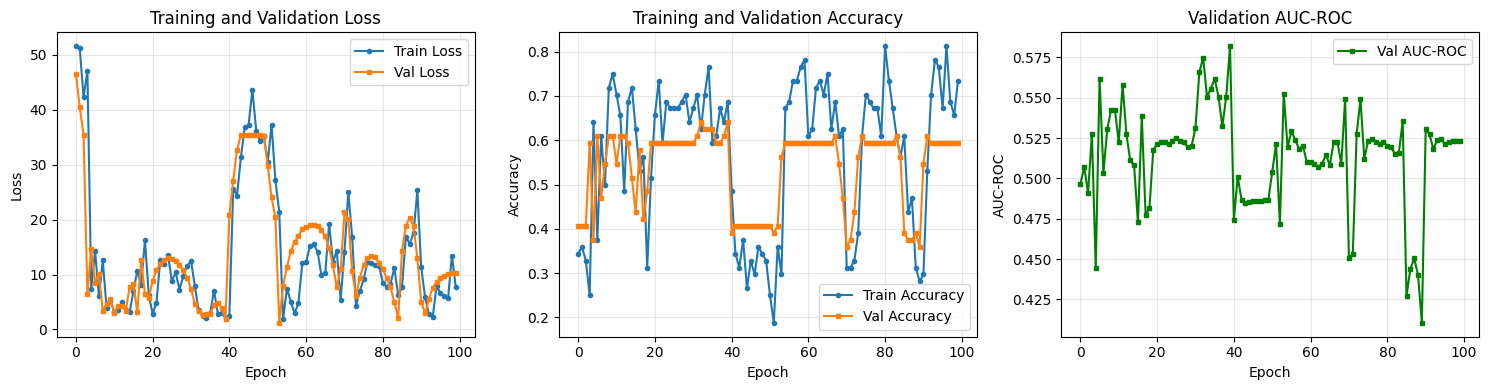


Final Training Metrics:
Train Loss:     7.8081
Train Accuracy: 0.7344
Val Loss:       10.3564
Val Accuracy:   0.5938
Val AUC-ROC:    0.5233


In [ ]:
# Plot training history
plot_training_history(history)

# Print final metrics
print("\nFinal Training Metrics:")
print("="*70)
print(f"Train Loss:     {history['train_loss'][-1]:.4f}")
print(f"Train Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Val Loss:       {history['val_loss'][-1]:.4f}")
print(f"Val Accuracy:   {history['val_acc'][-1]:.4f}")
print(f"Val AUC-ROC:    {history['val_auc'][-1]:.4f}")
print("="*70)

## Step 8: Save Model and Results

In [ ]:
print("\n" + "="*70)
print("STEP 8: Saving Results")
print("="*70)

# Save model state
model_path = os.path.join(SAVE_DIR, f"{EXPERIMENT_NAME}_model.pt")
torch.save(model.state_dict(), model_path)
print(f"✓ Model saved: {model_path}")

# Save graph
graph_path = os.path.join(SAVE_DIR, f"{EXPERIMENT_NAME}_graph.pkl")
processor.save_graph(graph_path)
print(f"✓ Graph saved: {graph_path}")

# Save training history
from drug_patient_qgnn import save_training_history
history_path = os.path.join(SAVE_DIR, f"{EXPERIMENT_NAME}_history.json")
save_training_history(history, history_path)
print(f"✓ History saved: {history_path}")

# Save configuration
import json
config = {
    'experiment_name': EXPERIMENT_NAME,
    'timestamp': timestamp,
    'spark': {
        'master': SPARK_MASTER,
        'driver_memory': SPARK_MEMORY,
        'executor_memory': SPARK_EXECUTOR_MEMORY,
        'num_executors': NUM_EXECUTORS,
        'partitions': n_partitions,
    },
    'data': {
        'data_dir': DATA_DIR,
        'max_drugs': MAX_DRUGS,
        'n_patients': N_PATIENTS,
        'interaction_rate': INTERACTION_RATE,
        'train_samples': n_train,
        'val_samples': n_val,
    },
    'model': {
        'num_qubits': NUM_QUBITS,
        'num_qlayers': NUM_QLAYERS,
        'hidden_dim': HIDDEN_DIM,
        'use_quantum': USE_QUANTUM,
    },
    'training': {
        'epochs': len(history['train_loss']),
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'val_split': VAL_SPLIT,
    },
    'results': {
        'final_train_loss': float(history['train_loss'][-1]),
        'final_train_acc': float(history['train_acc'][-1]),
        'final_val_loss': float(history['val_loss'][-1]),
        'final_val_acc': float(history['val_acc'][-1]),
        'final_val_auc': float(history['val_auc'][-1]),
    }
}

config_path = os.path.join(SAVE_DIR, f"{EXPERIMENT_NAME}_config.json")
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f"✓ Config saved: {config_path}")

print("\n" + "="*70)
print(f"All results saved to: {SAVE_DIR}")
print("="*70)


STEP 8: Saving Results
✓ Model saved: ./saved_models/spark_classical_q4_l2_20251116_162436_model.pt
Graph saved to ./saved_models/spark_classical_q4_l2_20251116_162436_graph.pkl
✓ Graph saved: ./saved_models/spark_classical_q4_l2_20251116_162436_graph.pkl
Training history saved to ./saved_models/spark_classical_q4_l2_20251116_162436_history.json
✓ History saved: ./saved_models/spark_classical_q4_l2_20251116_162436_history.json
✓ Config saved: ./saved_models/spark_classical_q4_l2_20251116_162436_config.json

All results saved to: ./saved_models


## Step 9: Cleanup Spark Session

In [ ]:
# Unpersist cached DataFrames
df_spark.unpersist()
train_df.unpersist()
val_df.unpersist()

# Stop Spark session
# spark.stop()  # Uncomment to stop Spark (useful if running multiple experiments)

print("\n✓ Spark DataFrames unpersisted")
print("\n⚠️  Spark session still active (comment out to stop)")


✓ Spark DataFrames unpersisted

⚠️  Spark session still active (comment out to stop)


## Summary

In [ ]:
print("\n" + "="*70)
print("EXPERIMENT SUMMARY")
print("="*70)
print(f"Experiment Name: {EXPERIMENT_NAME}")
print(f"Mode: {'Quantum' if USE_QUANTUM else 'Classical'} + Spark")
print(f"\nSpark Configuration:")
print(f"  Master: {SPARK_MASTER}")
print(f"  Partitions: {n_partitions}")
print(f"  Shuffle Partitions: {SHUFFLE_PARTITIONS}")
print(f"\nData:")
print(f"  Drugs: {stats['num_drugs']}")
print(f"  Patients: {stats['num_patients']}")
print(f"  Interactions: {stats['num_interactions']}")
print(f"  Train: {n_train}")
print(f"  Validation: {n_val}")
print(f"\nModel:")
print(f"  Qubits: {NUM_QUBITS} × 2 = {2*NUM_QUBITS}")
print(f"  Layers: {NUM_QLAYERS}")
print(f"  Parameters: {model.get_num_parameters():,}")
print(f"\nTraining:")
print(f"  Epochs: {len(history['train_loss'])}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"\nFinal Results:")
print(f"  Train Loss: {history['train_loss'][-1]:.4f}")
print(f"  Train Acc:  {history['train_acc'][-1]:.4f}")
print(f"  Val Loss:   {history['val_loss'][-1]:.4f}")
print(f"  Val Acc:    {history['val_acc'][-1]:.4f}")
print(f"  Val AUC:    {history['val_auc'][-1]:.4f}")
print(f"\nSaved to: {SAVE_DIR}/")
print("="*70)

print("\n✅ Distributed Training Complete!")


EXPERIMENT SUMMARY
Experiment Name: spark_classical_q4_l2_20251116_162436
Mode: Classical + Spark

Spark Configuration:
  Master: local[*]
  Partitions: 1263
  Shuffle Partitions: 200

Data:
  Drugs: 12636
  Patients: 200
  Interactions: 126360
  Train: 100826
  Validation: 25534

Model:
  Qubits: 4 × 2 = 8
  Layers: 2
  Parameters: 4,953

Training:
  Epochs: 100
  Batch Size: 64
  Learning Rate: 0.001

Final Results:
  Train Loss: 7.8081
  Train Acc:  0.7344
  Val Loss:   10.3564
  Val Acc:    0.5938
  Val AUC:    0.5233

Saved to: ./saved_models/

✅ Distributed Training Complete!
